## This file contains code for sentiment analysis of START data

In [10]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [11]:
# Load demographic abc data 
demographic_abcs = pd.read_csv('../data/demographic_abcs.csv')

/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_91697/3663584652.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["compound_sentiment"] = subset['sentiments'].apply(lambda x: x['compound'])
/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_91697/3663584652.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["compound_sentiment"] = subset['sentiments'].apply(lambda x: x['compound'])


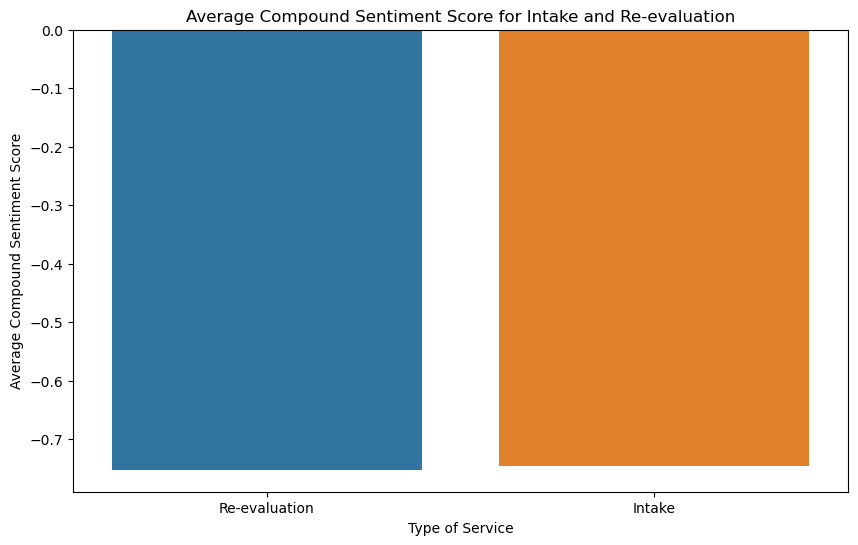

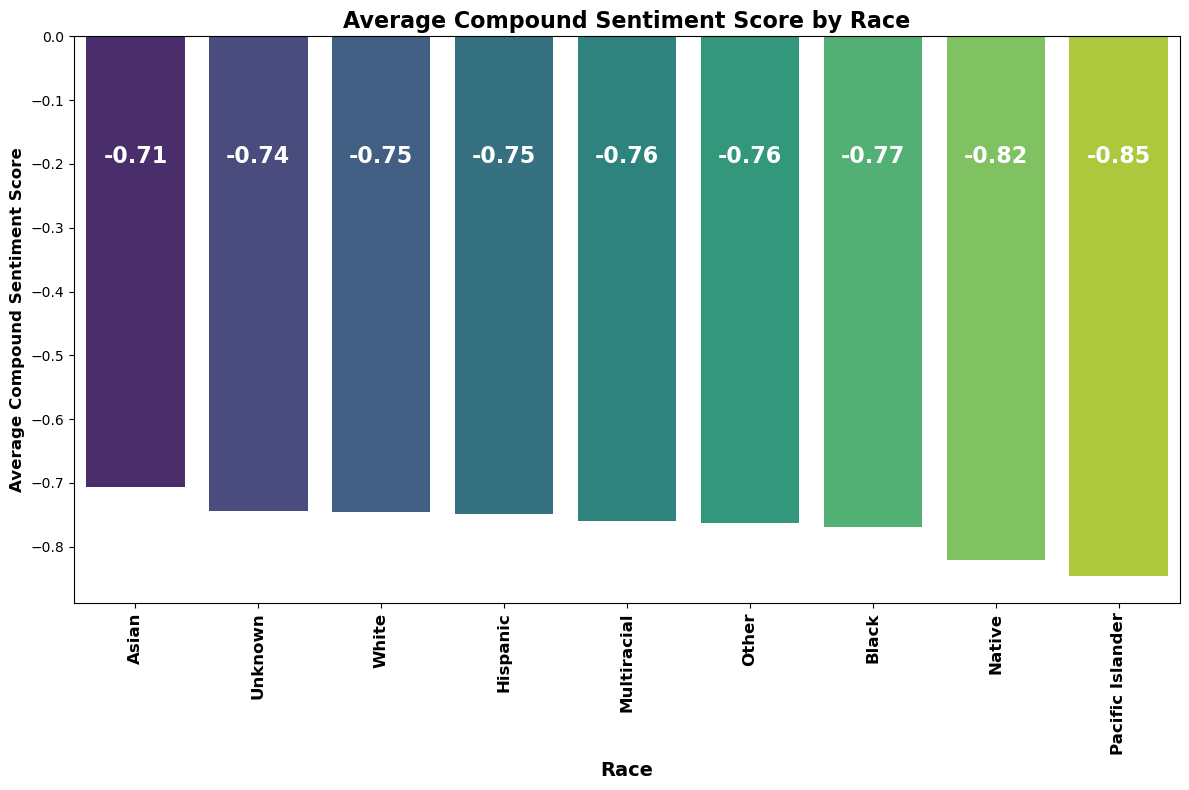

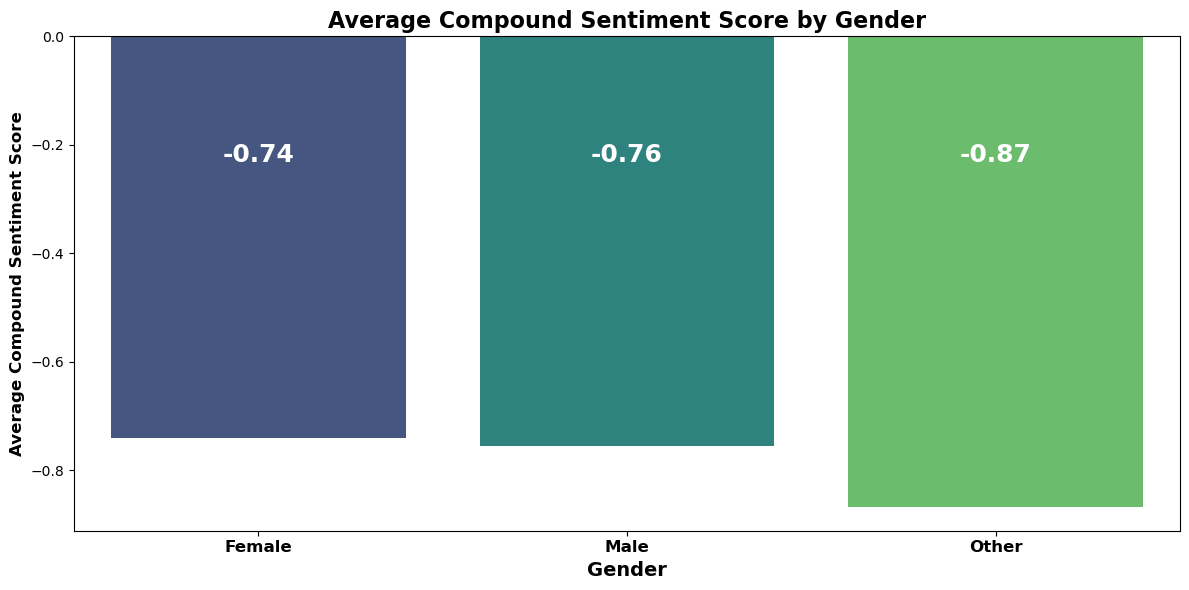

In [27]:
# function to get sentiments
def clean_and_analyze_sentiment(entry, sent_obj):
    sentiment_scores = sent_obj.polarity_scores(entry)
    return sentiment_scores

# function to calculate average sentiment scores by type of service (intake vs re-eval) 
def calculate_average_sentiment_by_service(demographic_abcs, service_type):
    subset = demographic_abcs[demographic_abcs['Type of Service'] == service_type]
    subset["compound_sentiment"] = subset['sentiments'].apply(lambda x: x['compound'])
    return subset["compound_sentiment"].mean()

# analyze the sentiments 
def analyze_and_extract_sentiments(demographic_abcs):
    demographic_abcs.dropna(subset=['Presenting problems at time of enrollment'], inplace=True)
    sent_obj = SentimentIntensityAnalyzer()

    # analyze sentiments
    demographic_abcs["sentiments"] = demographic_abcs['Presenting problems at time of enrollment'].apply(lambda x: clean_and_analyze_sentiment(x, sent_obj))
    demographic_abcs["compound_score"] = demographic_abcs["sentiments"].apply(lambda x: x['compound'])

In [31]:
# run sentiments
analyze_and_extract_sentiments(demographic_abcs)

# Calculate average sentiments for Intake and Re-evaluation
avg_reeval_sentiment = calculate_average_sentiment_by_service(demographic_abcs, "Re-evaluation")
avg_intake_sentiment = calculate_average_sentiment_by_service(demographic_abcs, "Intake")

# Create DataFrame for average sentiments
avg_sentiments_df = pd.DataFrame({
    "Type of Service": ["Re-evaluation", "Intake"],
    "Average Compound Sentiment": [avg_reeval_sentiment, avg_intake_sentiment]
})


/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_91697/3663584652.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["compound_sentiment"] = subset['sentiments'].apply(lambda x: x['compound'])
/var/folders/bw/cm4d5pyn7ns9dsb22kh7m9bc0000gn/T/ipykernel_91697/3663584652.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["compound_sentiment"] = subset['sentiments'].apply(lambda x: x['compound'])


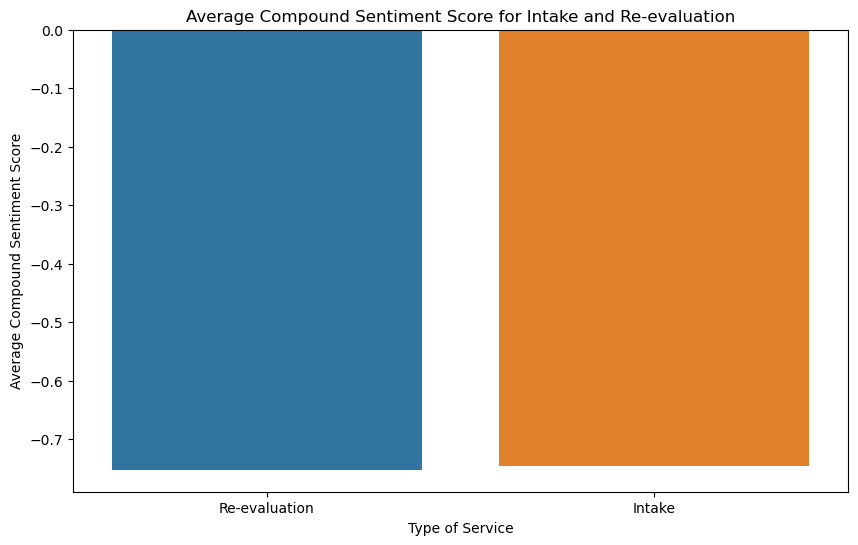

In [34]:

# Plot average sentiment scores for Intake vs Re-evaluation
plt.figure(figsize=(10, 6))
sns.barplot(x="Type of Service", y="Average Compound Sentiment", data=avg_sentiments_df)
plt.title("Average Compound Sentiment Score for Intake and Re-evaluation")
plt.ylabel("Average Compound Sentiment Score")
plt.xlabel("Type of Service")
plt.show()

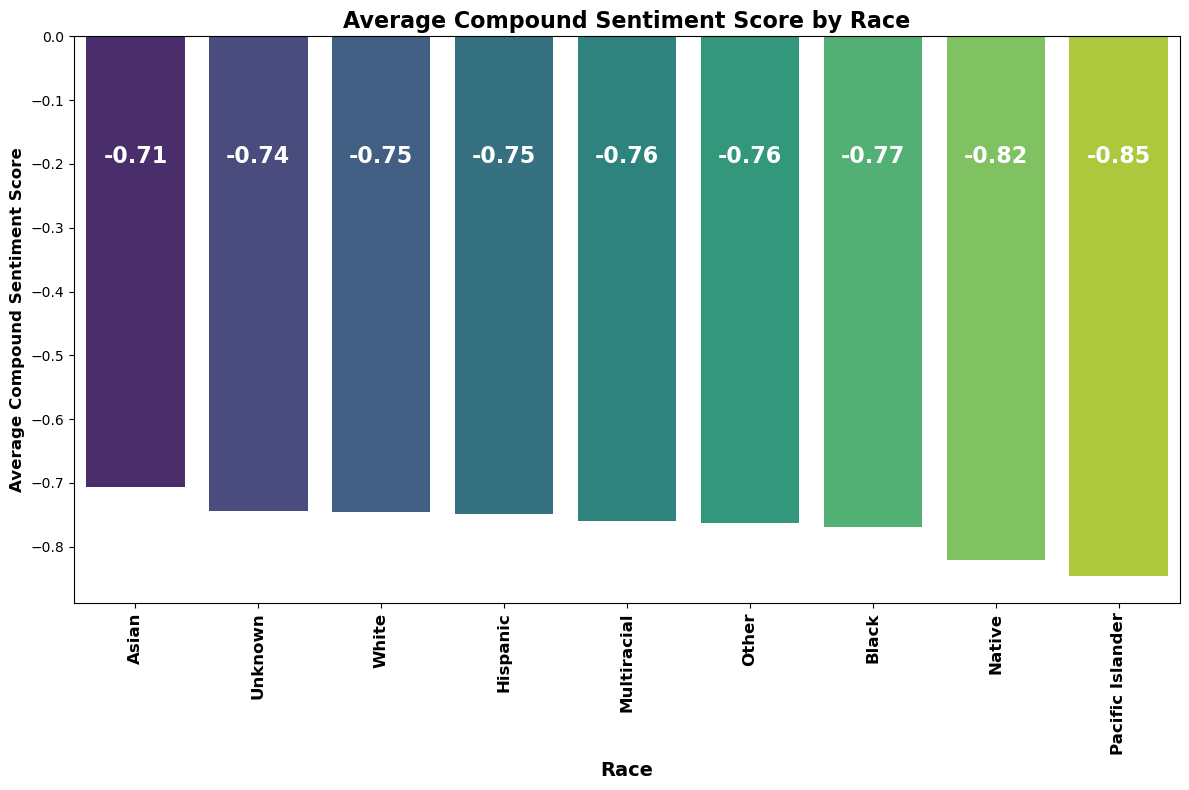

In [35]:
# calculate the sentiment scores by race
sentiment_by_race = demographic_abcs.groupby('Race')['compound_score'].mean().reset_index()
sentiment_by_race_sorted = sentiment_by_race.sort_values(by='compound_score', ascending=False)

# plt figure
plt.figure(figsize=(12, 8))
barplot = sns.barplot(data=sentiment_by_race_sorted, x='Race', y='compound_score', palette='viridis')
height = sentiment_by_race_sorted['compound_score'].max() + 0.5
for index, row in enumerate(sentiment_by_race_sorted.itertuples()):
    barplot.text(index, height, 
                 f'{row.compound_score:.2f}', 
                 color='white', 
                 ha="center", 
                 va="bottom", 
                 fontsize=16, 
                 fontweight='bold')
plt.title('Average Compound Sentiment Score by Race', fontsize=16, fontweight='bold')
plt.xlabel('Race', fontsize=14, fontweight='bold')
plt.ylabel('Average Compound Sentiment Score', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold', rotation=90)
plt.tight_layout()
plt.savefig('../output/sentiment_race.png')
plt.show()

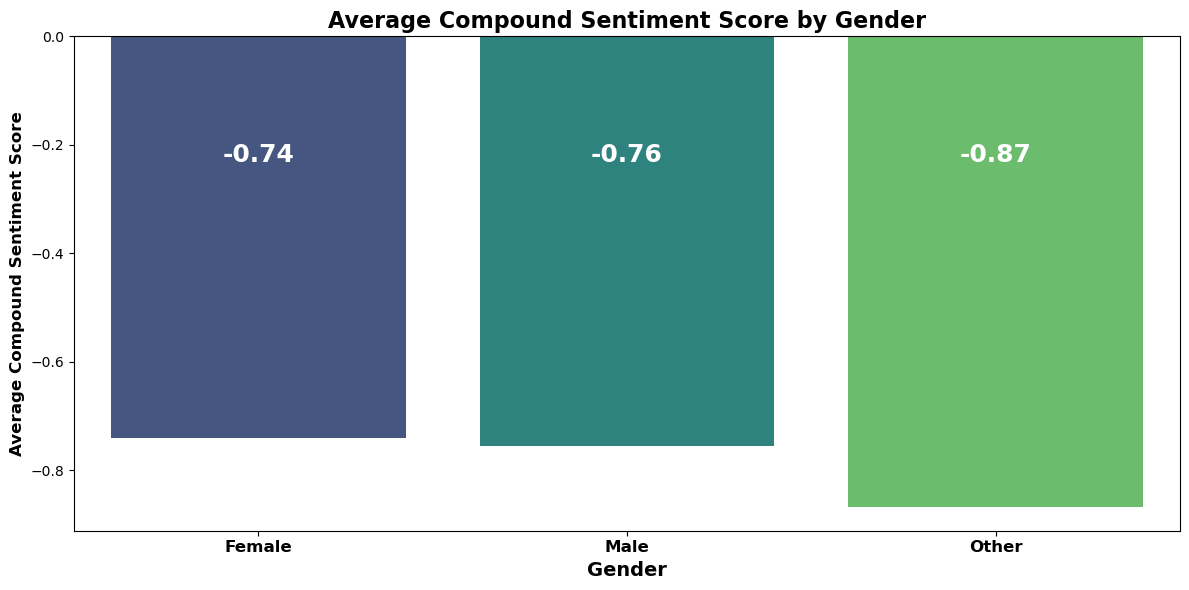

In [37]:
# Calculate sentiment scores by Gender
sentiment_by_gender = demographic_abcs.groupby('Gender')['compound_score'].mean().reset_index()
sentiment_by_gender_sorted = sentiment_by_gender.sort_values(by='compound_score', ascending=False)


# plt figure
plt.figure(figsize=(12, 6))
barplot = sns.barplot(data=sentiment_by_gender_sorted, x='Gender', y='compound_score', palette='viridis')
height = sentiment_by_gender_sorted['compound_score'].max() + 0.5
for index, row in sentiment_by_gender_sorted.iterrows():
    barplot.text(index, height, 
                 f'{row["compound_score"]:.2f}', 
                 color='white', 
                 ha="center", 
                 va="bottom", 
                 fontsize=18, 
                 fontweight='bold')
plt.title('Average Compound Sentiment Score by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=14, fontweight='bold')
plt.ylabel('Average Compound Sentiment Score', fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/sentiment_gender.png')
plt.show()
